In [ ]:
import cv2
import matplotlib.pyplot as plt
import os
import random
import numpy as np
import pandas as pd
from glob import glob
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision.models import resnet50
import torchvision.models as models

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import StratifiedKFold, train_test_split


class CFG:
    DATASET_PATH = "/kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT"
    SEARCH_ROOTS = [DATASET_PATH, "/kaggle/input"]
    IMG_EXTS = (".png", ".jpg", ".jpeg", ".bmp")
    IMG_SIZE = 224
    SEED = 42
    NUM_WORKERS = 2
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    SSL_BATCH = 64
    SSL_EPOCHS = 150
    SSL_LR = 3e-4
    SSL_WEIGHT_DECAY = 1e-4
    TEMP = 0.2
    PROJ_DIM = 128
    LP_BATCH = 32
    LP_EPOCHS = 30
    LP_LR = 1e-3
    VAL_SIZE = 0.2
    TEST_SIZE = 0.1
    ROI_CROP_PROB = 0.0
    INTENSITY_GAIN_RANGE = (0.8, 1.2)
    INTENSITY_BIAS_RANGE = (-15, 15)
    BG_ERASE_PROB = 0.4
    BG_ERASE_RATE = 0.1
    OUT_DIR = "/kaggle/working/busi_ssl"
    
    SSL_CKPT_VIT = "ssl_backbone_vit.pth"
    SSL_CKPT_RESNET = "ssl_backbone_resnet.pth"
    SSL_CKPT_CONVNEXT = "ssl_backbone_convnext.pth"
    LP_CKPT_VIT = "lp_classifier_vit.pth"
    LP_CKPT_RESNET = "lp_classifier_resnet.pth"
    LP_CKPT_CONVNEXT = "lp_classifier_convnext.pth"
    STACKING_CKPT = "stacking_ensemble.pth"

os.makedirs(CFG.OUT_DIR, exist_ok=True)

def set_seed(seed=CFG.SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

In [2]:
# =======================================
# 2. Data Indexing and Splitting
# =======================================
CLASS_MAP = {"benign": 0, "malignant": 1, "normal": 2}
INV_CLASS = {v: k for k, v in CLASS_MAP.items()}

def find_busi_root():
    candidates = []
    for root in CFG.SEARCH_ROOTS:
        if not os.path.exists(root):
            continue
        for p in glob(os.path.join(root, "**"), recursive=True):
            if all(os.path.isdir(os.path.join(p, c)) for c in ["benign", "malignant", "normal"]):
                candidates.append(p)
    if len(candidates) == 0:
        print("[WARN] BUSI root not found automatically.")
        return None
    candidates.sort(key=len)
    print("[INFO] Using BUSI root:", candidates[0])
    return candidates[0]

BUSI_ROOT = find_busi_root()
assert BUSI_ROOT is not None, "BUSI dataset path not found."

def match_mask_path(img_path: str):
    base, ext = os.path.splitext(img_path)
    p1 = base + "_mask" + ext
    if os.path.exists(p1): return p1
    folder = os.path.dirname(img_path)
    fname = os.path.basename(base) + "_mask" + ext
    for sub in ["mask", "masks", "GT", "ground_truth", "ground-truth"]:
        p2 = os.path.join(folder, sub, fname)
        if os.path.exists(p2): return p2
    p3 = base + ext
    if os.path.exists(p3) and ("mask" in p3.lower()): return p3
    return None

def build_index(root=BUSI_ROOT):
    rows = []
    for cls in CLASS_MAP.keys():
        for img_path in glob(os.path.join(root, cls, "**", "*"), recursive=True):
            if os.path.isdir(img_path): continue
            if not img_path.lower().endswith(CFG.IMG_EXTS): continue
            if "mask" in os.path.basename(img_path).lower(): continue
            mask_path = match_mask_path(img_path)
            if mask_path is None:
                if cls != "normal": pass
            rows.append({"image": img_path, "mask": mask_path if mask_path else "", "label": CLASS_MAP[cls], "cls": cls})
    df = pd.DataFrame(rows)
    print("Counts:\n", df["cls"].value_counts())
    return df

df_all = build_index(BUSI_ROOT)

if CFG.TEST_SIZE > 0:
    train_val_df, test_df = train_test_split(df_all, test_size=CFG.TEST_SIZE, stratify=df_all['cls'], random_state=CFG.SEED)
    train_df, val_df = train_test_split(train_val_df, test_size=CFG.VAL_SIZE / (1 - CFG.TEST_SIZE), stratify=train_val_df['cls'], random_state=CFG.SEED)
else:
    train_df, val_df = train_test_split(df_all, test_size=CFG.VAL_SIZE, stratify=df_all['cls'], random_state=CFG.SEED)
    test_df = None

print(f"Train samples: {len(train_df)} | Val samples: {len(val_df)} | Test samples: {len(test_df) if test_df is not None else 0}")


[INFO] Using BUSI root: /kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT
Counts:
 cls
benign       437
malignant    210
normal       133
Name: count, dtype: int64
Train samples: 546 | Val samples: 156 | Test samples: 78


In [ ]:
# =========================================
# 3. Datasets, Models and Loss Functions (ConvNeXt Backbone with ImageNet)
# =========================================
class USMaskSSL(Dataset):
    def __init__(self, df, size=CFG.IMG_SIZE, ssl=True):
        self.df = df
        self.size = size
        self.ssl = ssl

    def _read_gray(self, p):
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        return img

    def _roi_center(self, m):
        if m.max()==0: return self.size//2, self.size//2
        y,x = np.where(m>0)
        return int(x.mean()), int(y.mean())

    def _resize(self, x, m):
        x = cv2.resize(x, (self.size, self.size), interpolation=cv2.INTER_AREA)
        m = cv2.resize(m, (self.size, self.size), interpolation=cv2.INTER_NEAREST)
        return x, m

    def _aug_once(self, x, m):
        x, m = self._resize(x, m)
        angle = random.uniform(-5, 5)
        (h, w) = x.shape[:2]
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        x = cv2.warpAffine(x, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)
        m = cv2.warpAffine(m, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)
        
        if random.random() < 0.5: x = np.flip(x, 1); m = np.flip(m, 1)
        
        g0, g1 = CFG.INTENSITY_GAIN_RANGE
        gain = g0 + (g1 - g0) * random.random()
        b0, b1 = CFG.INTENSITY_BIAS_RANGE
        bias = np.random.randint(b0, b1 + 1)
        x = np.clip(x.astype(np.float32) * gain + bias, 0, 255).astype(np.uint8)
        if random.random() < CFG.BG_ERASE_PROB and m.max() > 0:
            bg = (m == 0); erase = np.random.rand(*bg.shape) < CFG.BG_ERASE_RATE
            x[bg & erase] = np.median(x)
        x = x.astype(np.float32) / 255.0; m = (m > 0).astype(np.float32)
        c2 = np.stack([x, m], axis=0)
        return torch.from_numpy(c2)

    def _ensure_mask(self, m, shape):
        if m is None: return np.zeros(shape, dtype=np.uint8)
        return (m > 0).astype(np.uint8) * 255

    def _load_pair(self, row):
        x = self._read_gray(row["image"])
        m = self._read_gray(row["mask"]) if row["mask"] else None
        if x is None: raise FileNotFoundError(row["image"])
        m = self._ensure_mask(m, x.shape)
        return x, m

    def __getitem__(self, idx):
        row = self.df.iloc[idx]; x, m = self._load_pair(row)
        if self.ssl:
            v1 = self._aug_once(x, m); v2 = self._aug_once(x, m)
            return v1, v2
        else:
            img = self._aug_once(x, m)
            label = int(row["label"]) if "label" in row else -1
            return img, label

    def __len__(self):
        return len(self.df)

class USMaskSup(USMaskSSL):
    def __init__(self, df, size=CFG.IMG_SIZE, ssl=False):
        super().__init__(df, size=size, ssl=ssl)

class ProjHead(nn.Module):
    def __init__(self, d, out):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d, d), nn.ReLU(inplace=True), nn.Linear(d, out))
    def forward(self, x):
        return F.normalize(self.net(x), dim=1)

class ConvNeXtBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        original_conv1_weights = self.model.features[0][0].weight.data
        new_conv1 = nn.Conv2d(2, 96, kernel_size=(4, 4), stride=(4, 4))
        with torch.no_grad():
            new_conv1.weight[:, 0, :, :] = original_conv1_weights[:, 0, :, :]
            new_conv1.weight[:, 1, :, :] = original_conv1_weights[:, 0, :, :]
        self.model.features[0][0] = new_conv1
        self.model.classifier[2] = nn.Identity()

    def forward(self, x):
        return self.model(x)

class Classifier(nn.Module):
    def __init__(self, backbone, dim, num_classes=3):
        super().__init__()
        self.backbone = backbone
        self.fc = nn.Linear(dim, num_classes)
    def forward(self, x):
        h = self.backbone(x)
        return self.fc(h)

def build_backbone(name="convnext"):
    if name == "convnext":
        model = ConvNeXtBackbone()
        dim = 768
    elif name == "resnet":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        model.conv1 = nn.Conv2d(2, 64, kernel_size=7, stride=2, padding=3, bias=False)
        dim = model.fc.in_features
        model.fc = nn.Identity()
    elif name == "vit":
        model = timm.create_model('vit_tiny_patch16_224.augreg_in21k_ft_in1k', pretrained=True)
        model.patch_embed.proj = nn.Conv2d(2, model.patch_embed.proj.out_channels, kernel_size=16, stride=16)
        dim = model.head.in_features
        model.head = nn.Identity()
    else:
        raise ValueError("Backbone name must be 'convnext', 'resnet', or 'vit'")
    return model, dim

def nt_xent(z1, z2, T=CFG.TEMP):
    z1 = F.normalize(z1, dim=1); z2 = F.normalize(z2, dim=1)
    z = torch.cat([z1, z2], dim=0)
    sim = z @ z.t()
    B = z1.size(0)
    mask = torch.eye(2 * B, device=z.device, dtype=torch.bool)
    sim = sim[~mask].view(2 * B, 2 * B - 1)
    pos = (z1 * z2).sum(dim=1)
    pos = torch.cat([pos, pos], dim=0).unsqueeze(1)
    logits = torch.cat([pos, sim], dim=1) / T
    labels = torch.zeros(2 * B, dtype=torch.long, device=z.device)
    return F.cross_entropy(logits, labels)

In [4]:
# =========================================
# 4. Training and Evaluation Logic
# =========================================
def ssl_pretrain(train_df, backbone_name="convnext"):
    ds = USMaskSSL(train_df, ssl=True)
    dl = DataLoader(ds, batch_size=CFG.SSL_BATCH, shuffle=True, num_workers=CFG.NUM_WORKERS, pin_memory=True, drop_last=True)
    backbone, dim = build_backbone(name=backbone_name)
    backbone = backbone.to(CFG.DEVICE)
    proj = ProjHead(d=dim, out=CFG.PROJ_DIM).to(CFG.DEVICE)
    params = list(backbone.parameters()) + list(proj.parameters())
    opt = torch.optim.AdamW(params, lr=CFG.SSL_LR, weight_decay=CFG.SSL_WEIGHT_DECAY)
    scaler = torch.cuda.amp.GradScaler(enabled=(CFG.DEVICE == "cuda"))
    backbone.train(); proj.train()
    best = 1e9
    
    ckpt_name = getattr(CFG, f"SSL_CKPT_{backbone_name.upper()}")

    for epoch in range(1, CFG.SSL_EPOCHS + 1):
        t0 = time.time(); losses = []
        for v1, v2 in dl:
            v1 = v1.to(CFG.DEVICE, non_blocking=True).float(); v2 = v2.to(CFG.DEVICE, non_blocking=True).float()
            with torch.cuda.amp.autocast(enabled=(CFG.DEVICE == "cuda")):
                h1 = backbone(v1); h2 = backbone(v2)
                z1 = proj(h1); z2 = proj(h2)
                loss = nt_xent(z1, z2, T=CFG.TEMP)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            losses.append(loss.item())
        avg = float(np.mean(losses)) if losses else 0.0; dt = time.time() - t0
        print(f"[SSL] Epoch {epoch}/{CFG.SSL_EPOCHS} loss={avg:.4f} time={dt:.1f}s")
        if avg < best:
            best = avg
            torch.save(backbone.state_dict(), os.path.join(CFG.OUT_DIR, ckpt_name))
    print("[SSL] Best loss:", best)

def get_class_weights(df):
    counts = df['label'].value_counts().reindex([0,1,2]).fillna(0).values.astype(float)
    weights = counts.sum() / np.clip(counts, 1, None)
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32, device=CFG.DEVICE)

def build_sampler(df):
    labels = df['label'].values
    class_counts = df['label'].value_counts().to_dict()
    iw = {c: 1.0/max(1, class_counts[c]) for c in class_counts}
    sample_weights = np.array([iw[l] for l in labels], dtype=np.float32)
    return WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

def train_supervised(train_df, val_df, backbone_name="convnext"):
    stage = 'linear_probe'
    train_ds = USMaskSup(train_df, ssl=False)
    val_ds = USMaskSup(val_df, ssl=False)
    sampler = build_sampler(train_df)
    train_dl = DataLoader(train_ds, batch_size=CFG.LP_BATCH, sampler=sampler, num_workers=CFG.NUM_WORKERS, pin_memory=True)
    val_dl = DataLoader(val_ds, batch_size=CFG.LP_BATCH, shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True)
    lr = CFG.LP_LR; epochs = CFG.LP_EPOCHS

    backbone, dim = build_backbone(name=backbone_name)
    ssl_ckpt_name = getattr(CFG, f"SSL_CKPT_{backbone_name.upper()}")
    lp_ckpt_name = getattr(CFG, f"LP_CKPT_{backbone_name.upper()}")
    ssl_path = os.path.join(CFG.OUT_DIR, ssl_ckpt_name)
    
    if os.path.exists(ssl_path):
        backbone.load_state_dict(torch.load(ssl_path, map_location=CFG.DEVICE))
        print(f"[INFO] Loaded SSL backbone: {ssl_path}")
    else:
        print("[INFO] No SSL backbone found. Starting from scratch.")

    backbone = backbone.to(CFG.DEVICE)
    for param in backbone.parameters(): param.requires_grad = False
    
    model = Classifier(backbone, dim=dim, num_classes=3).to(CFG.DEVICE)
    class_weights = get_class_weights(train_df)
    criterion = nn.CrossEntropyLoss(weight=class_weights) if not CFG.USE_FOCAL else FocalLoss(alpha=class_weights)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    scaler = torch.cuda.amp.GradScaler(enabled=(CFG.DEVICE == "cuda"))

    best_acc = 0.0
    best_path = os.path.join(CFG.OUT_DIR, lp_ckpt_name)

    for epoch in range(1, epochs + 1):
        model.train(); train_losses, correct, total = [], 0, 0
        for (x, y) in train_dl:
            x = x.to(CFG.DEVICE).float(); y = y.to(CFG.DEVICE).long()
            with torch.cuda.amp.autocast(enabled=(CFG.DEVICE=="cuda")):
                logits = model(x); loss = criterion(logits, y)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            train_losses.append(loss.item()); pred = logits.argmax(1)
            correct += (pred==y).sum().item(); total += y.size(0)
        train_acc = correct/total if total else 0

        model.eval(); val_losses, vcorrect, vtotal, all_logits, all_true = [], 0, 0, [], []
        with torch.no_grad():
            for (x, y) in val_dl:
                x = x.to(CFG.DEVICE).float(); y = y.to(CFG.DEVICE).long()
                with torch.cuda.amp.autocast(enabled=(CFG.DEVICE=="cuda")):
                    logits = model(x); loss = criterion(logits, y)
                val_losses.append(loss.item()); pred = logits.argmax(1)
                vcorrect += (pred==y).sum().item(); vtotal += y.size(0)
                all_logits.append(logits.softmax(1).detach().cpu().numpy())
                all_true.append(y.detach().cpu().numpy())
        val_acc = vcorrect/vtotal if vtotal else 0.0
        all_logits = np.concatenate(all_logits, axis=0) if len(all_logits) else np.zeros((0,3))
        all_true = np.concatenate(all_true, axis=0) if len(all_true) else np.zeros((0,))
        try:
            ovr_auc = roc_auc_score(all_true, all_logits, multi_class='ovr') if len(np.unique(all_true))>1 else float('nan')
        except Exception: ovr_auc = float('nan')

        print(f"[{stage}] Epoch {epoch} | train_loss={np.mean(train_losses):.4f} acc={train_acc:.3f} | val_loss={np.mean(val_losses):.4f} acc={val_acc:.3f} AUC={ovr_auc:.3f}")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), best_path)

    print(f"[{stage}] Best Val Acc: {best_acc:.4f} | Saved: {best_path}")
    return best_path

def evaluate(model_path, df, stage_name="Evaluation", backbone_name="convnext"):
    ds = USMaskSup(df, ssl=False)
    dl = DataLoader(ds, batch_size=CFG.LP_BATCH, shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True)
    backbone, dim = build_backbone(name=backbone_name)
    ssl_ckpt_name = getattr(CFG, f"SSL_CKPT_{backbone_name.upper()}")
    ssl_path = os.path.join(CFG.OUT_DIR, ssl_ckpt_name)
    if os.path.exists(ssl_path):
        backbone.load_state_dict(torch.load(ssl_path, map_location=CFG.DEVICE))
    backbone = backbone.to(CFG.DEVICE)
    model = Classifier(backbone, dim=dim, num_classes=3).to(CFG.DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=CFG.DEVICE))
    model.eval()

    ALL_P, ALL_Y, ALL_S = [], [], []
    with torch.no_grad():
        for (x, y) in dl:
            x = x.to(CFG.DEVICE).float(); y = y.to(CFG.DEVICE).long()
            s = model(x).softmax(1); p = s.argmax(1)
            ALL_P.append(p.cpu().numpy()); ALL_Y.append(y.cpu().numpy()); ALL_S.append(s.cpu().numpy())

    y_true = np.concatenate(ALL_Y); y_pred = np.concatenate(ALL_P); y_score = np.concatenate(ALL_S)

    print(f"\n[{stage_name} Classification Report]")
    print(classification_report(y_true, y_pred, target_names=[INV_CLASS[i] for i in range(3)]))

    cm = confusion_matrix(y_true, y_pred, labels=list(CLASS_MAP.values()))
    fig, ax = plt.subplots(figsize=(8, 8))
    cax = ax.matshow(cm, cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    fig.colorbar(cax)
    ax.set_xticklabels([''] + list(CLASS_MAP.keys()))
    ax.set_yticklabels([''] + list(CLASS_MAP.keys()))
    plt.xlabel('Predicted')
    plt.ylabel('True')
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, f'{val}', ha='center', va='center', color='red')
    plt.show()

    try:
        if len(np.unique(y_true)) > 1:
            fig, ax = plt.subplots(figsize=(8, 8))
            for i in range(3):
                y_true_binary = (y_true == i).astype(int)
                y_score_class = y_score[:, i]
                if len(np.unique(y_true_binary)) > 1:
                    RocCurveDisplay.from_predictions(y_true_binary, y_score_class, name=f"Class: {INV_CLASS[i]}", ax=ax)
                else:
                    print(f"Warning: Cannot plot ROC for class {INV_CLASS[i]} as only one class label is present.")

            ax.plot([0, 1], [0, 1], 'k--', label='Random guess')
            plt.title('Receiver Operating Characteristic (ROC) Curve (One-vs-Rest)')
            plt.legend()
            plt.show()

            ovr_auc = roc_auc_score(y_true, y_score, multi_class='ovr')
            print(f"OVR AUC: {ovr_auc:.4f}")
    except Exception as e:
        print(f"AUC/ROC plotting error: {e}")

Device: cuda
Using Backbone: CONVNEXT

Displaying 5 random pairs of augmented images from the training set:


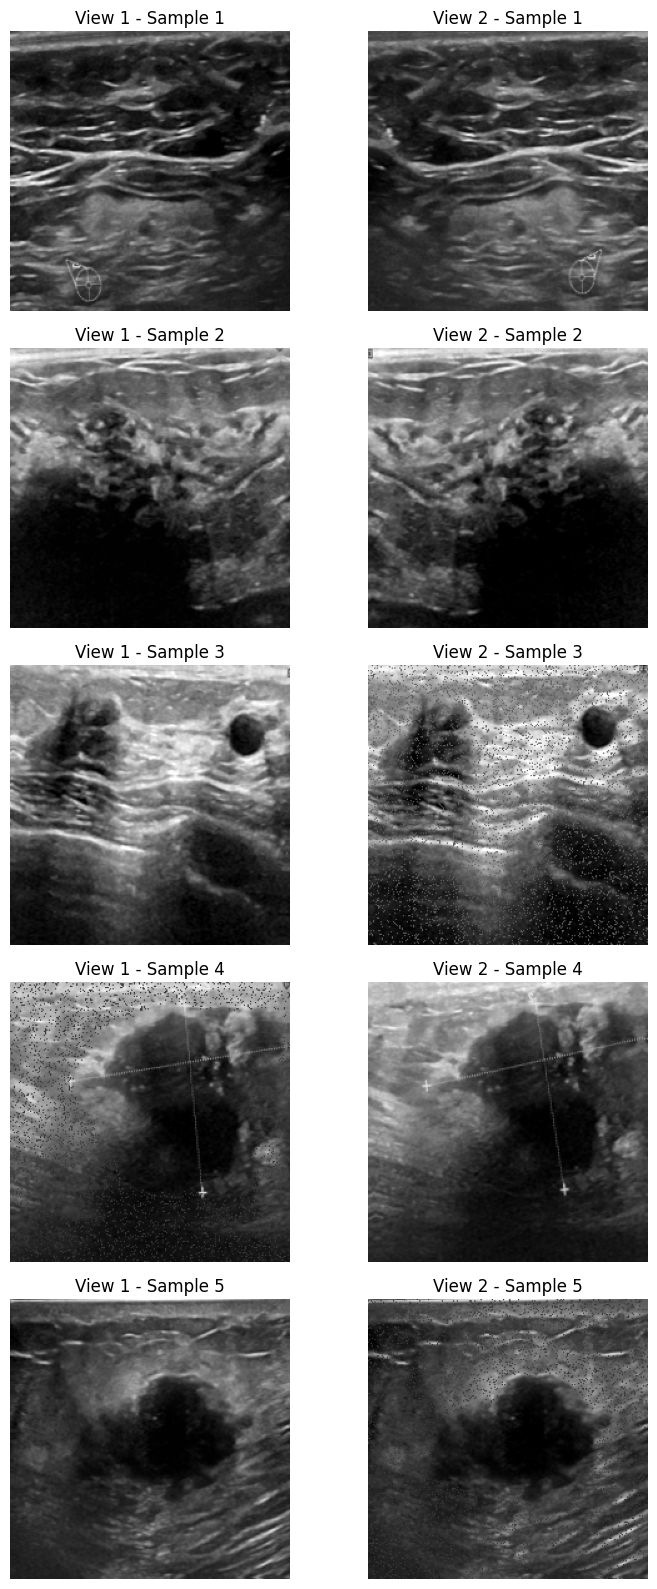


Starting SSL Pretraining...


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth
100%|██████████| 109M/109M [00:00<00:00, 200MB/s] 
/tmp/ipykernel_36/914603167.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(CFG.DEVICE == "cuda"))
/tmp/ipykernel_36/914603167.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(CFG.DEVICE == "cuda")):


[SSL] Epoch 1/150 loss=3.2726 time=25.4s
[SSL] Epoch 2/150 loss=2.0067 time=22.7s
[SSL] Epoch 3/150 loss=1.6769 time=22.7s
[SSL] Epoch 4/150 loss=1.5699 time=22.7s
[SSL] Epoch 5/150 loss=1.4910 time=22.7s
[SSL] Epoch 6/150 loss=1.4450 time=22.7s
[SSL] Epoch 7/150 loss=1.3887 time=22.7s
[SSL] Epoch 8/150 loss=1.3375 time=22.7s
[SSL] Epoch 9/150 loss=1.3457 time=22.7s
[SSL] Epoch 10/150 loss=1.3119 time=22.7s
[SSL] Epoch 11/150 loss=1.3078 time=22.7s
[SSL] Epoch 12/150 loss=1.2894 time=22.7s
[SSL] Epoch 13/150 loss=1.2741 time=22.7s
[SSL] Epoch 14/150 loss=1.2663 time=22.8s
[SSL] Epoch 15/150 loss=1.2620 time=22.6s
[SSL] Epoch 16/150 loss=1.2589 time=22.6s
[SSL] Epoch 17/150 loss=1.2365 time=22.7s
[SSL] Epoch 18/150 loss=1.2466 time=22.6s
[SSL] Epoch 19/150 loss=1.2329 time=22.7s
[SSL] Epoch 20/150 loss=1.2243 time=22.7s
[SSL] Epoch 21/150 loss=1.2273 time=22.7s
[SSL] Epoch 22/150 loss=1.2189 time=22.7s
[SSL] Epoch 23/150 loss=1.2207 time=22.7s
[SSL] Epoch 24/150 loss=1.2109 time=22.8s
[

/tmp/ipykernel_36/914603167.py:76: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(CFG.DEVICE == "cuda"))
/tmp/ipykernel_36/914603167.py:85: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(CFG.DEVICE=="cuda")):
/tmp/ipykernel_36/914603167.py:97: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(CFG.DEVICE=="cuda")):


[linear_probe] Epoch 1 | train_loss=0.7630 acc=0.615 | val_loss=0.5758 acc=0.609 AUC=nan


...

/tmp/ipykernel_36/914603167.py:85: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(CFG.DEVICE=="cuda")):
/tmp/ipykernel_36/914603167.py:97: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(CFG.DEVICE=="cuda")):


[linear_probe] Epoch 29 | train_loss=0.0283 acc=0.996 | val_loss=0.0888 acc=0.987 AUC=nan


/tmp/ipykernel_36/914603167.py:85: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(CFG.DEVICE=="cuda")):
/tmp/ipykernel_36/914603167.py:97: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(CFG.DEVICE=="cuda")):


[linear_probe] Epoch 30 | train_loss=0.0171 acc=1.000 | val_loss=0.0792 acc=0.981 AUC=0.992
[linear_probe] Best Val Acc: 0.9936 | Saved: /kaggle/working/busi_ssl/lp_classifier_convnext.pth

[Validation (Linear Probe) Classification Report]
              precision    recall  f1-score   support

      benign       0.98      1.00      0.99        87
   malignant       1.00      0.95      0.98        42
      normal       1.00      1.00      1.00        27

    accuracy                           0.99       156
   macro avg       0.99      0.98      0.99       156
weighted avg       0.99      0.99      0.99       156



/tmp/ipykernel_36/914603167.py:149: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([''] + list(CLASS_MAP.keys()))
/tmp/ipykernel_36/914603167.py:150: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([''] + list(CLASS_MAP.keys()))


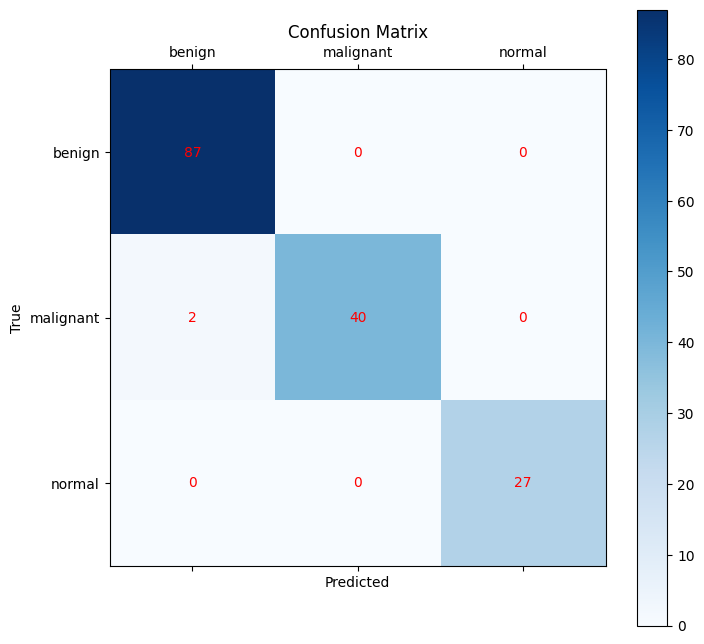

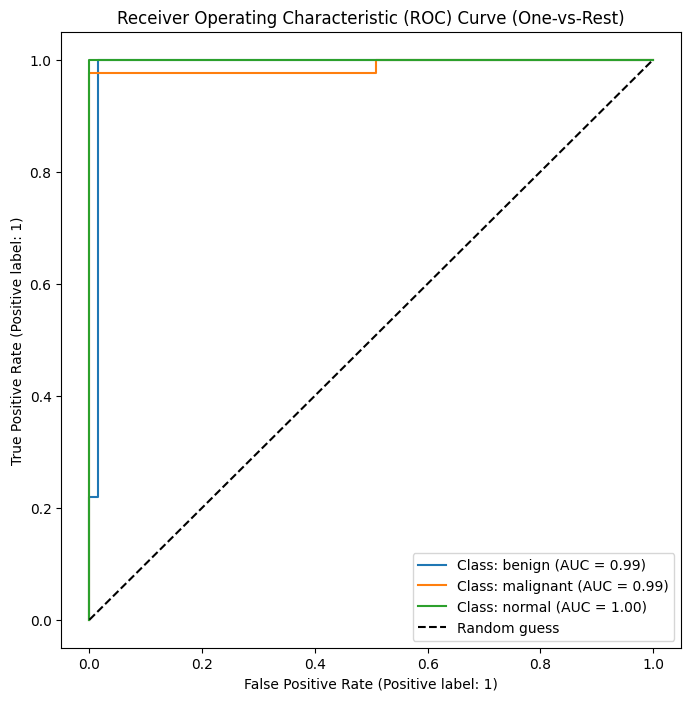

OVR AUC: 0.9922

[TEST Evaluation]

[Test (Linear Probe) Classification Report]
              precision    recall  f1-score   support

      benign       0.96      0.98      0.97        44
   malignant       0.95      0.90      0.93        21
      normal       1.00      1.00      1.00        13

    accuracy                           0.96        78
   macro avg       0.97      0.96      0.96        78
weighted avg       0.96      0.96      0.96        78



/tmp/ipykernel_36/914603167.py:149: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([''] + list(CLASS_MAP.keys()))
/tmp/ipykernel_36/914603167.py:150: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([''] + list(CLASS_MAP.keys()))


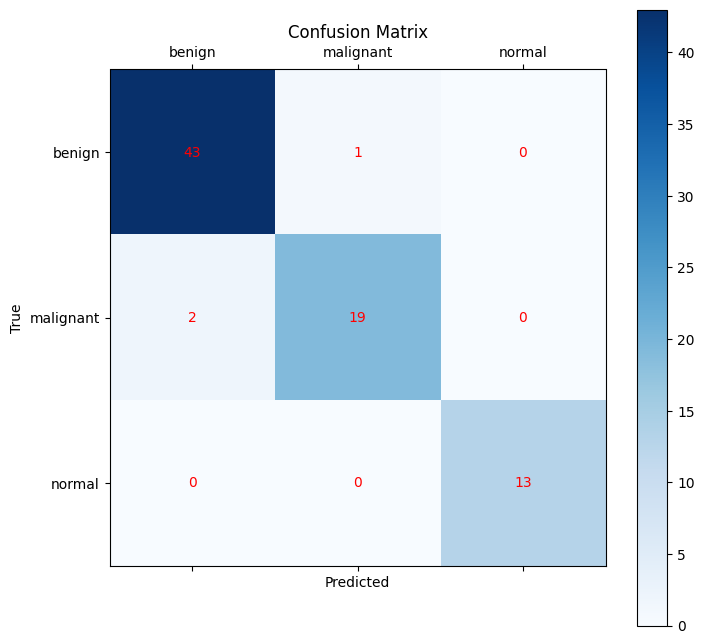

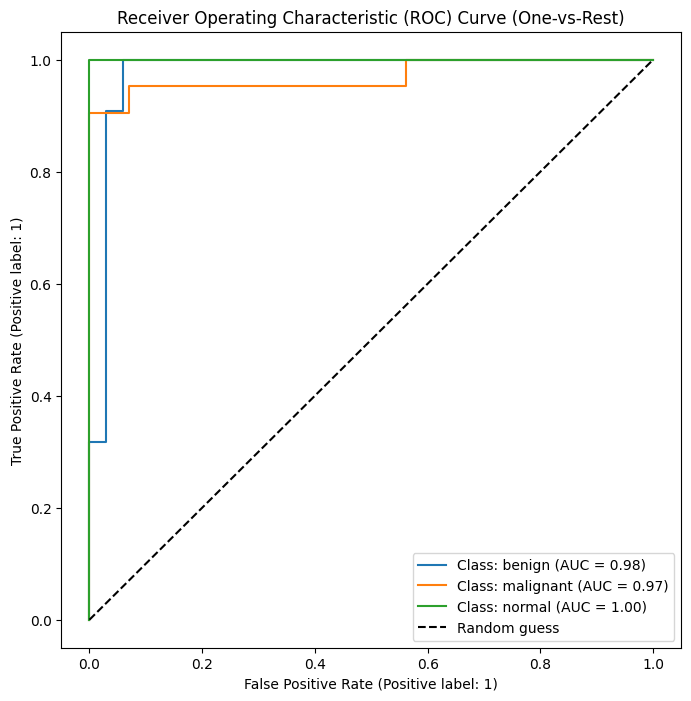

OVR AUC: 0.9824

Done.


In [5]:

 # ===========================
# 5. Run the Pipeline (ConvNeXt Backbone with ImageNet)
# ===========================
if __name__ == "__main__":
    BACKBONE_NAME = "convnext"
    print("Device:", CFG.DEVICE)
    print("Using Backbone:", BACKBONE_NAME.upper())

    print("\nDisplaying 5 random pairs of augmented images from the training set:")
    display_ds = USMaskSSL(train_df, ssl=True)
    fig, axes = plt.subplots(5, 2, figsize=(8, 16))
    for i in range(5):
        v1, v2 = display_ds[random.randint(0, len(display_ds) - 1)]
        axes[i, 0].imshow(v1[0].numpy(), cmap='gray')
        axes[i, 0].set_title(f"View 1 - Sample {i+1}")
        axes[i, 0].axis('off')
        axes[i, 1].imshow(v2[0].numpy(), cmap='gray')
        axes[i, 1].set_title(f"View 2 - Sample {i+1}")
        axes[i, 1].axis('off')
    plt.tight_layout()
    plt.show()

    print("\nStarting SSL Pretraining...")
    ssl_pretrain(train_df, backbone_name=BACKBONE_NAME)

    print("\nStarting Linear Probe...")
    lp_path = train_supervised(train_df, val_df, backbone_name=BACKBONE_NAME)
    evaluate(lp_path, val_df, stage_name="Validation (Linear Probe)", backbone_name=BACKBONE_NAME)

    if test_df is not None and len(test_df) > 0:
        print("\n[TEST Evaluation]")
        evaluate(lp_path, test_df, stage_name="Test (Linear Probe)", backbone_name=BACKBONE_NAME)

    train_df.to_csv(os.path.join(CFG.OUT_DIR, "train_split.csv"), index=False)
    val_df.to_csv(os.path.join(CFG.OUT_DIR, "val_split.csv"), index=False)
    if test_df is not None:
        test_df.to_csv(os.path.join(CFG.OUT_DIR, "test_split.csv"), index=False)
    print("\nDone.")